In [2]:
# =========================
# 1. Import libraries
# =========================

import ast                                  # Convert list-like strings into real Python lists
import pandas as pd                         # DataFrames and data analysis
from datasets import load_dataset           # Load the jobs dataset
import matplotlib.pyplot as plt             # Plotting and chart formatting

In [3]:
# =========================
# 2. Load the dataset
# =========================

dataset = load_dataset('lukebarousse/data_jobs')   # Load the jobs dataset
df = dataset['train'].to_pandas()                  # Convert it into a pandas DataFrame

In [4]:
# =========================
# 3. Clean the data
# =========================

# Convert posting dates from text into datetime objects
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Convert job_skills from a string like "['python', 'sql']"
# into a real Python list like ['python', 'sql']
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [5]:
# =========================
# 4. Filter to U.S. Data Engineer jobs
# =========================

df_DE_US = df[
    (df['job_title_short'] == 'Data Engineer') &      # Only Data Engineer roles
    (df['job_country'] == 'United States')            # Only U.S. jobs
].copy()

# Remove rows where yearly salary is missing
df_DE_US = df_DE_US.dropna(subset=['salary_year_avg'])

In [6]:
# =========================
# 5. Explode job skills
# =========================

# One job posting may contain multiple skills:
# ['python', 'sql', 'aws']
#
# explode() turns that into separate rows:
# python
# sql
# aws
df_DE_US_exploded = df_DE_US.explode('job_skills')

In [7]:
# =========================
# 6. Calculate salary + demand statistics for each skill
# =========================

df_DE_US_group = (
    df_DE_US_exploded
    .groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])              # count = demand, median = typical salary
)

df_DE_US_group.head()

,count,median
job_skills,,
airflow,458,140000.0
airtable,2,122500.0
alteryx,57,115000.0
angular,27,140000.0
angular.js,1,116600.0


In [8]:
# =========================
# 7. Top 10 highest-paid skills
# =========================

df_DE_top_pay = (
    df_DE_US_group
    .sort_values(
        by='median',
        ascending=False                    # Highest salary first
    )
    .head(10)                              # Keep top 10
)

df_DE_top_pay

,count,median
job_skills,,
mongo,78,208114.0
vue,1,200000.0
solidity,1,192500.0
node,24,190000.0
ggplot2,2,176250.0
macos,2,172000.0
clojure,2,170866.5
atlassian,18,169860.0
rust,7,165000.0


In [9]:
# =========================
# 8. Top 10 most in-demand skills
# =========================

df_DE_skills = (
    df_DE_US_group
    .sort_values(
        by='count',
        ascending=False                    # Most frequently requested first
    )
    .head(10)                              # Keep top 10 skills
    .sort_values(
        by='median',
        ascending=False                    # Then order these 10 by salary
    )
)

df_DE_skills

,count,median
job_skills,,
kafka,536,145000.00000
nosql,519,140000.00000
spark,968,137410.15625
java,732,137000.00000
redshift,514,135000.00000
aws,1313,131000.00000
snowflake,765,130700.00000
python,2007,127794.50000
sql,2110,125000.00000


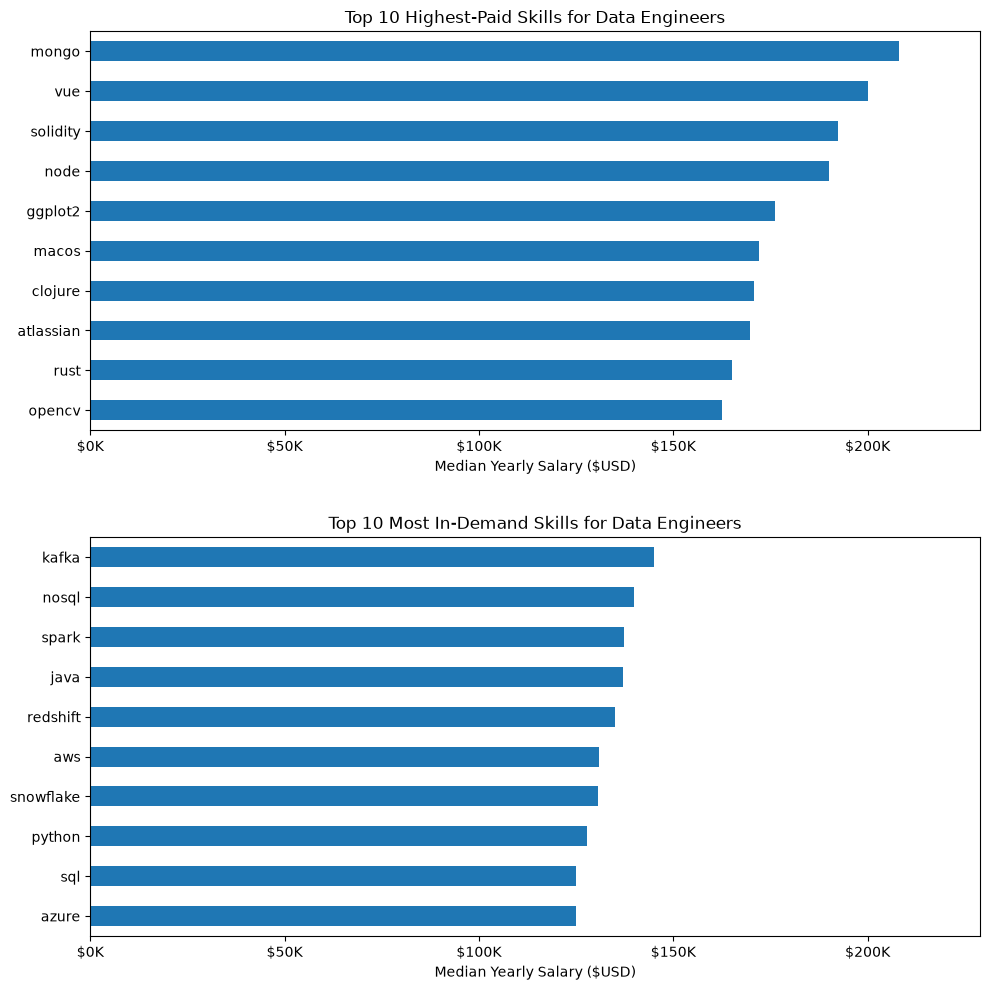

In [10]:
# =========================
# 9. Create two clean horizontal bar charts
# =========================

# Create 2 rows and 1 column of charts
fig, ax = plt.subplots(
    2,
    1,
    figsize=(10, 10)                       # Make the figure large enough to avoid overlap
)

# -------------------------
# Top chart: highest-paid skills
# -------------------------

df_DE_top_pay[::-1].plot(
    kind='barh',                           # Horizontal bar chart
    y='median',                            # Bar length = median salary
    ax=ax[0],                              # Draw on first subplot
    legend=False                           # Hide unnecessary legend
)

ax[0].set_title('Top 10 Highest-Paid Skills for Data Engineers')
ax[0].set_ylabel('')                       # Remove default y-axis label
ax[0].set_xlabel('Median Yearly Salary ($USD)')

# Format salary values like 120000 -> $120K
ax[0].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f'${int(x / 1000)}K'
    )
)

# -------------------------
# Bottom chart: most in-demand skills
# -------------------------

df_DE_skills[::-1].plot(
    kind='barh',
    y='median',                            # Still plotting median salary
    ax=ax[1],                              # Draw on second subplot
    legend=False
)

ax[1].set_title('Top 10 Most In-Demand Skills for Data Engineers')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Yearly Salary ($USD)')

ax[1].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f'${int(x / 1000)}K'
    )
)

# Give both charts the same x-axis range
# so salary comparisons are visually fair
max_salary = max(
    df_DE_top_pay['median'].max(),
    df_DE_skills['median'].max()
)

ax[0].set_xlim(0, max_salary * 1.10)
ax[1].set_xlim(0, max_salary * 1.10)

# Add spacing between the two subplots
fig.tight_layout(h_pad=3)

# Display the final dashboard
plt.show()